# 1. Import Ntuple

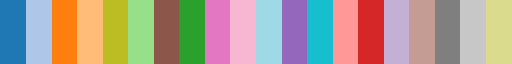

In [1]:
%load_ext autoreload
%autoreload 2

import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import sys
# sys.path.insert(0, "/home/belle/zhangboy/B2SW/2025_VirginiaTech/sysvar/src/")
sys.path.append('/home/belle/zhangboy/inclusive_R_D/')
import utilities as util

training_variables = util.training_variables
columns = util.all_relevant_variables
cut = util.offline_cut
lgb_tight = util.lgb_tight
lgb_loose = util.lgb_loose
lgb_comb = util.lgb_comb

util.my_cmap

In [2]:
# Load data files
MC_4S_wc = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/4S_run2_deimos_BDT_e_3.root:MC_wc_e_loose'],
                          library="np",
                          cut = cut,
                          filter_branch=lambda branch: branch.name in columns)

data_4S_wc = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/4S_run2_deimos_BDT_e_3.root:Data_wc_e_loose'],
                          library="np",
                          cut = cut,
                          filter_branch=lambda branch: branch.name in columns)

df_mc_4S_wc = pd.DataFrame(MC_4S_wc)
df_data_4S_wc = pd.DataFrame(data_4S_wc)

In [3]:
import sysvar
import warnings

e_eff_table = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/e_efficiency_MC16rd_run2_TwophotonEe.csv')
pi_e_fake = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/pi_e_fake_MC16rd_run2.csv')
K_e_fake = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/K_e_fake_MC16rd_run2.csv')

tables = {(11, 11): e_eff_table,
          # (11, 211): pi_e_fake,
          (11, 321): K_e_fake}
thresholds = {11: ('electronIDNN', 0.9)}

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sysvar.add_weights_to_dataframe('ell_BFbrems', # Specify your particle prefix here, e.g. "DST_D0_K"
                             df_mc_4S_wc,
                             systematic='custom_PID',
                             custom_tables=tables,
                             custom_thresholds=thresholds)

k_eff_table = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/k_efficiency_MC16rd_run2.csv')
pi_k_fake = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/pi_k_fake_MC16rd_run2.csv')

tables = {(321, 321): k_eff_table,
          (321, 211): pi_k_fake,}
thresholds = {321: ('kaonIDNN', 0.9)}

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sysvar.add_weights_to_dataframe('K', # Specify your particle prefix here, e.g. "DST_D0_K"
                             df_mc_4S_wc,
                             systematic='custom_PID',
                             custom_tables=tables,
                             custom_thresholds=thresholds)

pi_eff_table = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/pi_efficiency_MC16rd_run2.csv')
k_pi_fake = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/k_pi_fake_MC16rd_run2.csv')

tables = {(211, 211): pi_eff_table,
          (211, 321): k_pi_fake,}
thresholds = {211: ('pionIDNN', 0.1)}

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sysvar.add_weights_to_dataframe('pi1', # Specify your particle prefix here, e.g. "DST_D0_K"
                             df_mc_4S_wc,
                             systematic='custom_PID',
                             custom_tables=tables,
                             custom_thresholds=thresholds)
    sysvar.add_weights_to_dataframe('pi2', # Specify your particle prefix here, e.g. "DST_D0_K"
                             df_mc_4S_wc,
                             systematic='custom_PID',
                             custom_tables=tables,
                             custom_thresholds=thresholds)

df_mc_4S_wc["total_PIDweight"] = df_mc_4S_wc[["ell_BFbrems_Weight", "K_Weight",'pi1_Weight','pi2_Weight']].product(axis = 1)

Required variables: ['ell_BFbrems_cosTheta', 'ell_BFbrems_charge', 'ell_BFbrems_p', 'ell_BFbrems_PDG', 'ell_BFbrems_mcPDG']
Required variables: ['K_cosTheta', 'K_charge', 'K_p', 'K_PDG', 'K_mcPDG']
Required variables: ['pi1_cosTheta', 'pi1_charge', 'pi1_p', 'pi1_PDG', 'pi1_mcPDG']
Required variables: ['pi2_cosTheta', 'pi2_charge', 'pi2_p', 'pi2_PDG', 'pi2_mcPDG']


/tmp/ipykernel_3472017/4278395439.py:56: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_mc_4S_wc["total_PIDweight"] = df_mc_4S_wc[["ell_BFbrems_Weight", "K_Weight",'pi1_Weight','pi2_Weight']].product(axis = 1)


In [22]:
samples_wc=util.classify_mc_dict(df_mc_4S_wc, 'e', template=False)
mpl_wc=util.mpl(samples_wc,df_data_4S_wc)
for name, df in samples_wc.items():
    print(name, len(df))

bkg_fakeD 113386
bkg_fakeL 1248
bkg_fakeTracks 3326
bkg_continuum 2065
bkg_combinatorial 63098
bkg_hadronicB_secondaryL 1287
bkg_other_TDTl 0
$D\tau\nu$ 0
$D^\ast\tau\nu$ 0
$D\ell\nu$ 0
$D^\ast\ell\nu$ 0
$D^{\ast\ast}\tau\nu$ 0
$D^{\ast\ast}\ell\nu$_narrow 0
$D^{\ast\ast}\ell\nu$_broad 0
$D\ell\nu$_gap 0
bkg_other_signal 0



[bkg_combinatorial] N=63098  sum(BB_weight)=61797.126


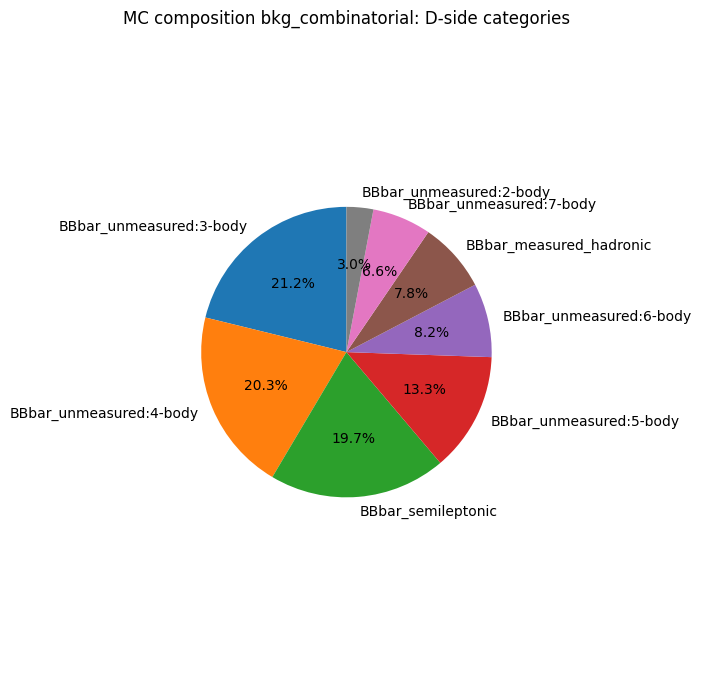


[bkg_hadronicB_secondaryL] N=1287  sum(BB_weight)=1256.061


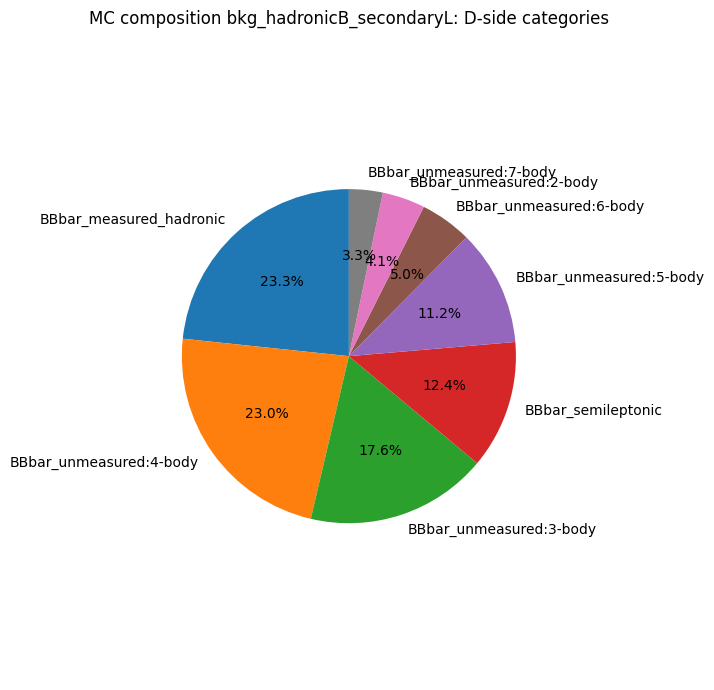

In [23]:
weights={'BBbar_measured_hadronic':1,
         'BBbar_semileptonic': 1,
         'BBbar_unmeasured:2-body':1,
         'BBbar_unmeasured:3-body':1,
         'BBbar_unmeasured:4-body':1,
         'BBbar_unmeasured:5-body':1,
         'BBbar_unmeasured:6-body':1,
         'BBbar_unmeasured:7-body':1,}

samples_wc_sub = util.reweight_BBbar_background(samples_wc, weight_map = weights, out_weight_col = "BB_weight",
                    weight_ell_side = False, verbose= True, cap_nbody = None, warn_missing_weight_keys = True,)
for name, df in samples_wc_sub.items():
    df['total_weight'] = df["total_PIDweight"] * df['BB_weight']
mpl_wc_sub=util.mpl(samples_wc_sub,df_data_4S_wc)

# 2. Check Data vs. MC

cut= 1.855<D_M<1.885 and fakeD_prob<0.1


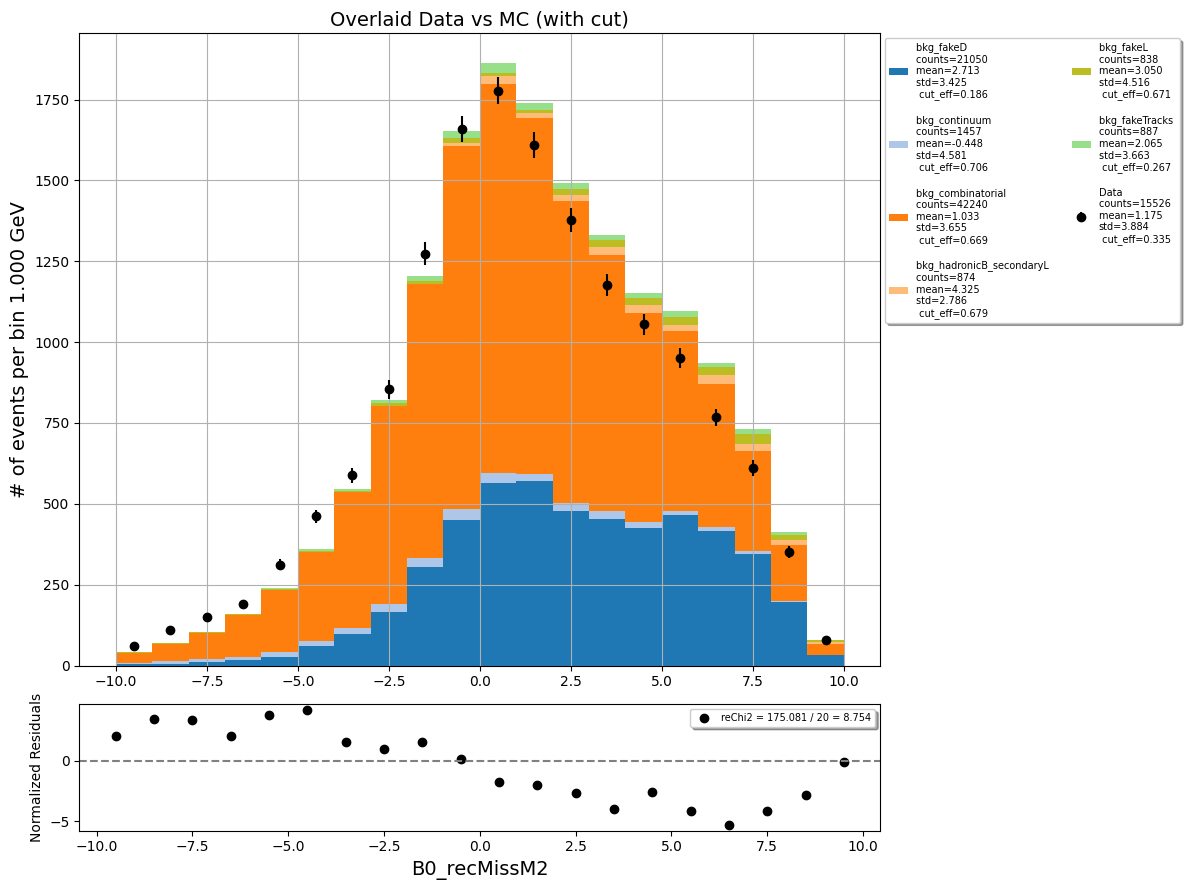

In [7]:
b1 = np.linspace(-10,10,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl_wc.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut='1.855<D_M<1.885 and fakeD_prob<0.1',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight') # 'total_PID_weigh'

cut= (D_M<1.855 or 1.885<D_M) and fakeD_prob<0.1


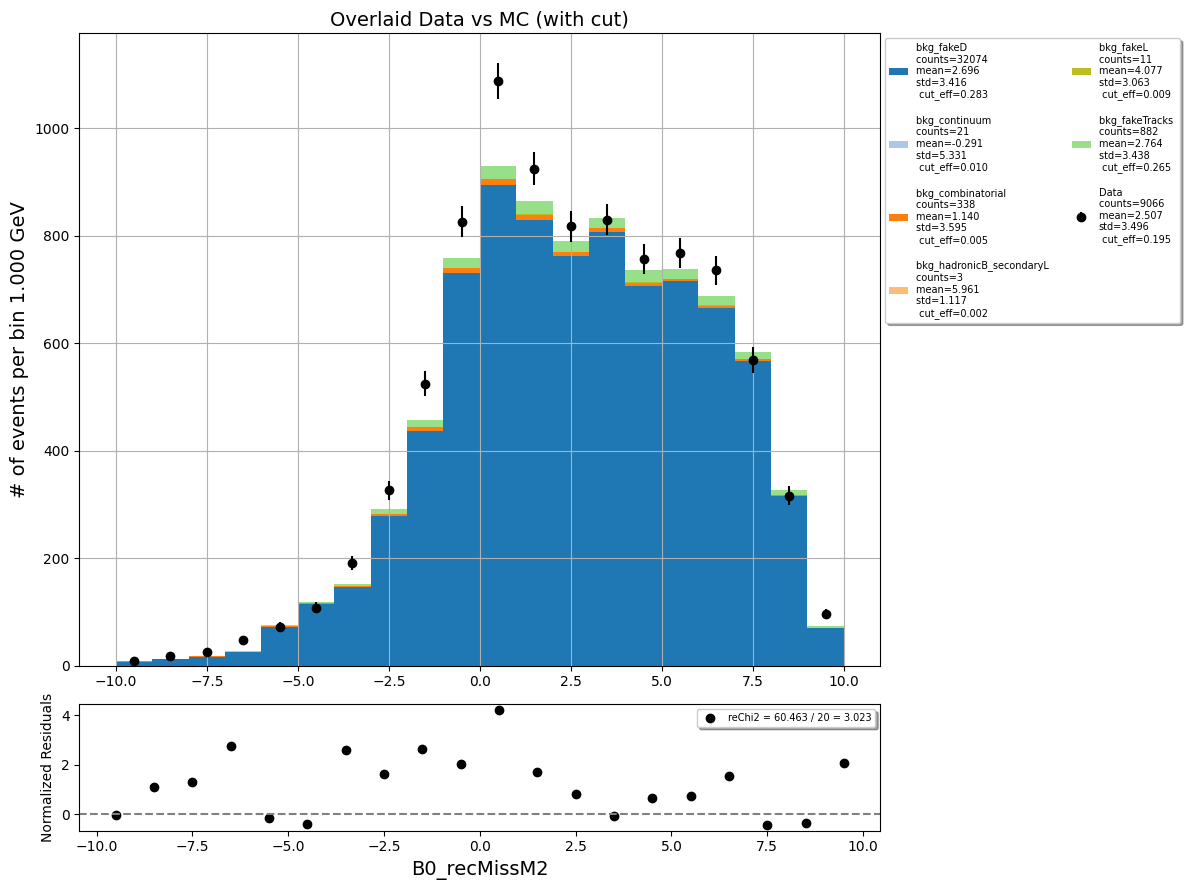

In [11]:
b1 = np.linspace(-10,10,21)
weights={'all_mc':0.25 * 1.038,}
data_hist_all, mc_hist_all = mpl_wc.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut='(D_M<1.855 or 1.885<D_M) and fakeD_prob<0.1',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

cut= 1.855<D_M<1.885 and fakeD_prob<0.1


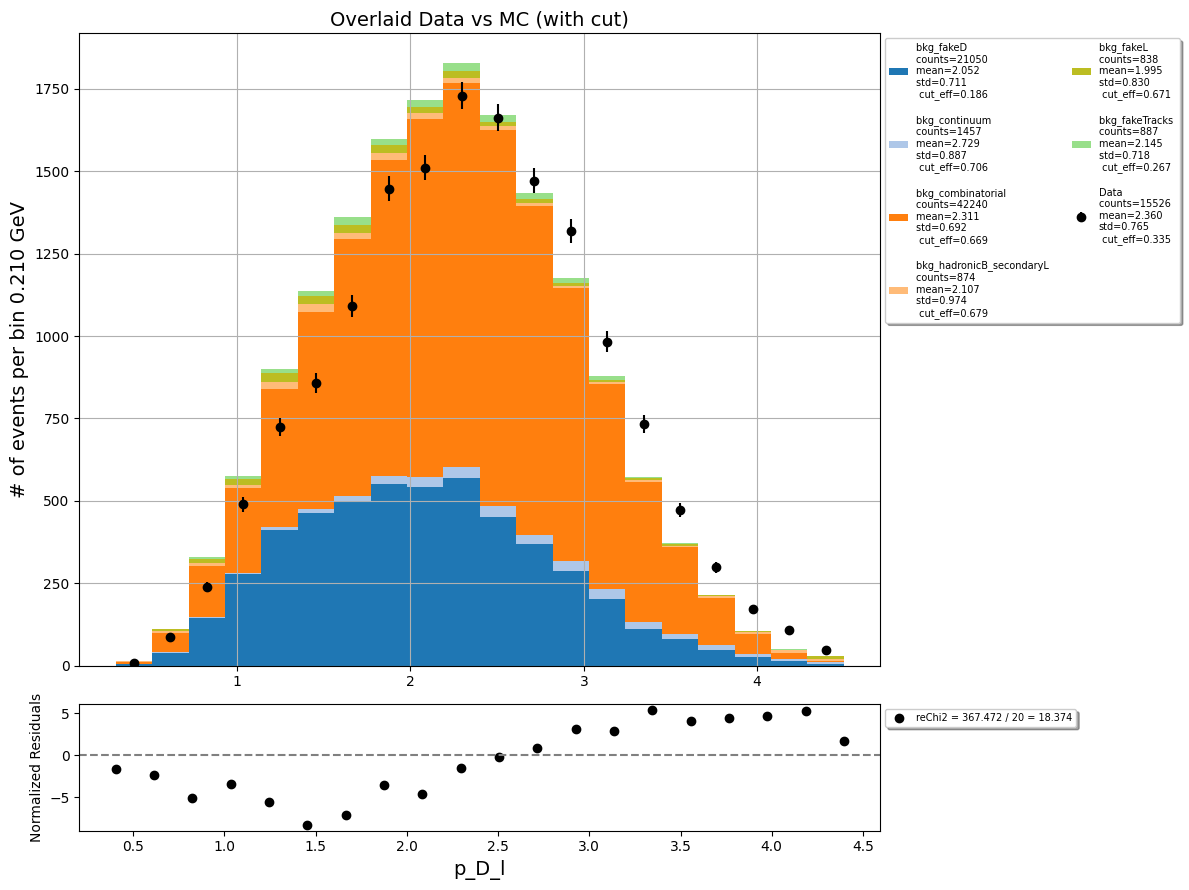

In [14]:
b1 = np.linspace(0.3,4.5,21)
weights={'all_mc':0.25,}
data_hist_all, mc_hist_all = mpl_wc.plot_data_mc_stacked(
    variable='p_D_l',bins=b1,cut='1.855<D_M<1.885 and fakeD_prob<0.1',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight') # 'total_PID_weigh'

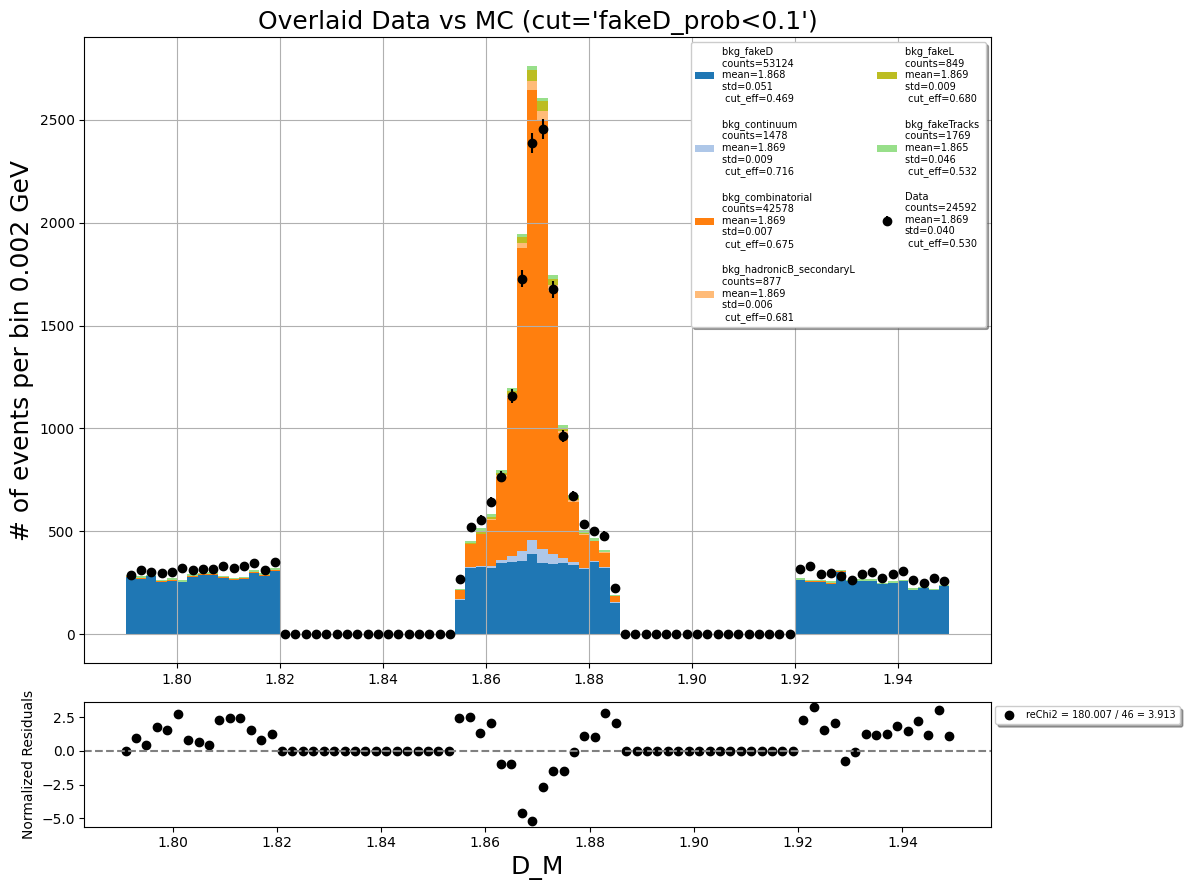

In [15]:
# showing the fake D and sidebands in D_M
b1 = np.linspace(1.79,1.95,81)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl_wc.plot_data_mc_stacked(
    variable='D_M',bins=b1,cut='fakeD_prob<0.1',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,text_fs=18, weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight') # 'total_PID_weigh'

cut= 1.855<D_M<1.885 and fakeD_prob<0.1


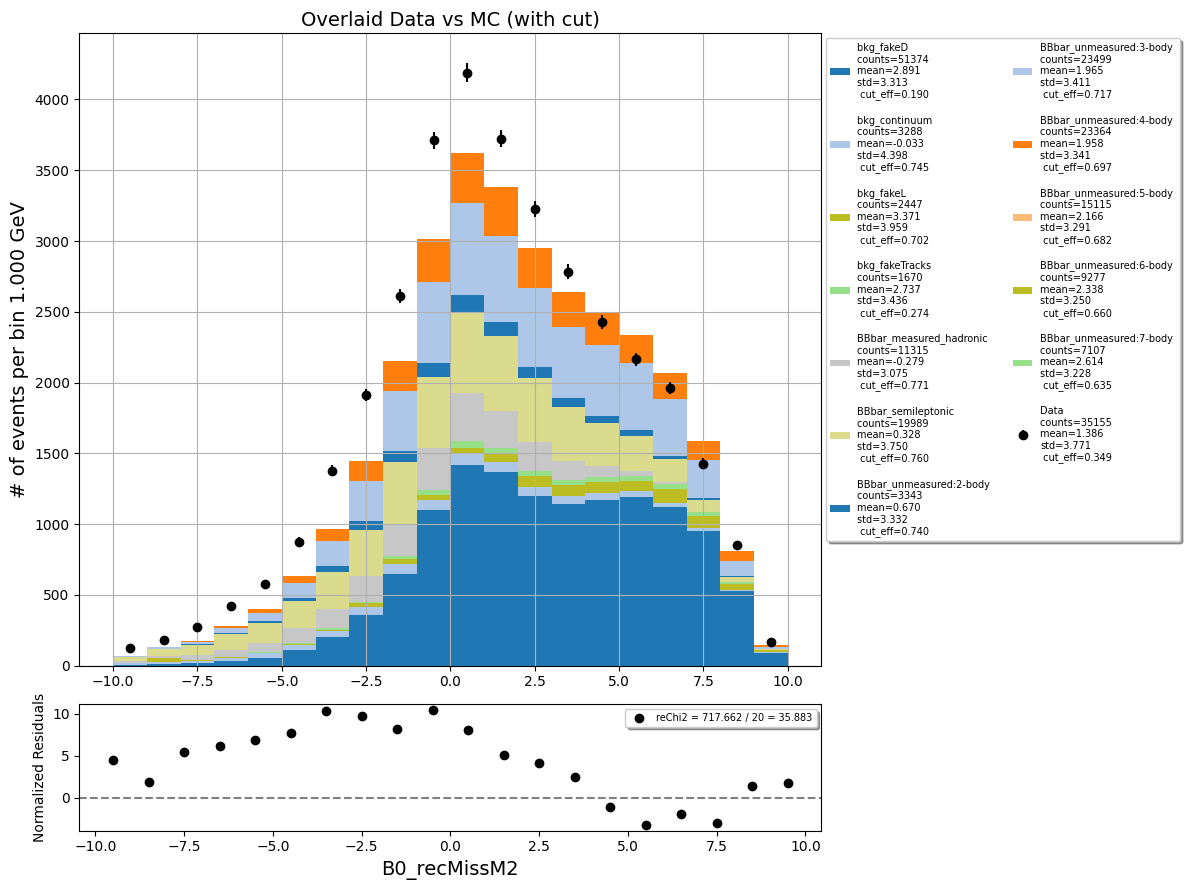

In [32]:
b1 = np.linspace(-10,10,21)
weights={'all_mc':0.25,
         'BBbar_measured_hadronic':0.25 * 1,
         'BBbar_semileptonic': 0.25 * 1,
         'BBbar_unmeasured:2-body':0.25 * 1,
         'BBbar_unmeasured:3-body':0.25 * 1,
         'BBbar_unmeasured:4-body':0.25 * 0.5,
         'BBbar_unmeasured:5-body':0,
         'BBbar_unmeasured:6-body':0,
         'BBbar_unmeasured:7-body':0,}
data_hist_all, mc_hist_all = mpl_wc_sub.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut='1.855<D_M<1.885 and fakeD_prob<0.1',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight') # 'total_PID_weigh'

cut= 1.855<D_M<1.885 and B0_vtxReChi2>3 and experiment<18


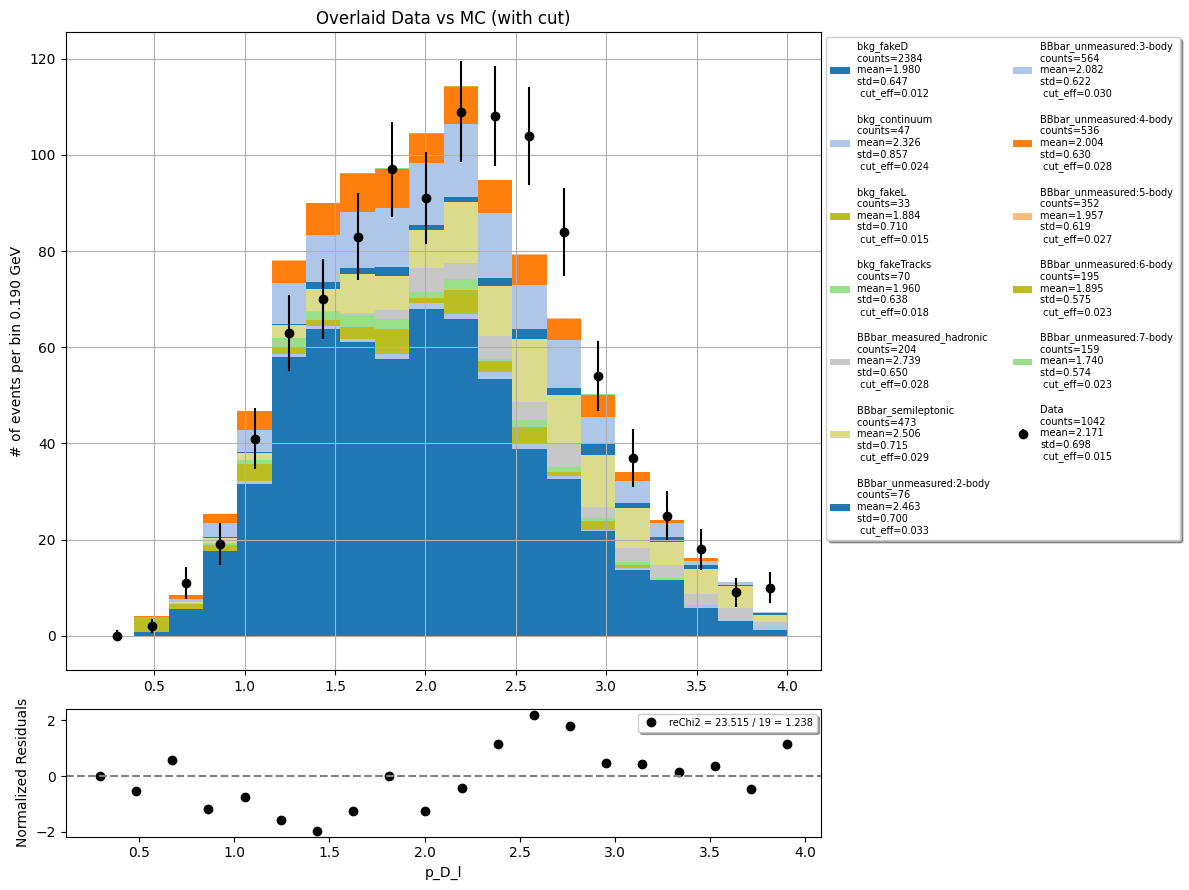

In [18]:
b1 = np.linspace(0.2,4,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl_wc.plot_data_mc_stacked(
    variable='p_D_l',bins=b1,cut='1.855<D_M<1.885 and B0_vtxReChi2>3 and experiment<18',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight') # 'total_PID_weigh'

cut= 1.855<D_M<1.885 and B0_vtxReChi2>3 and experiment<18


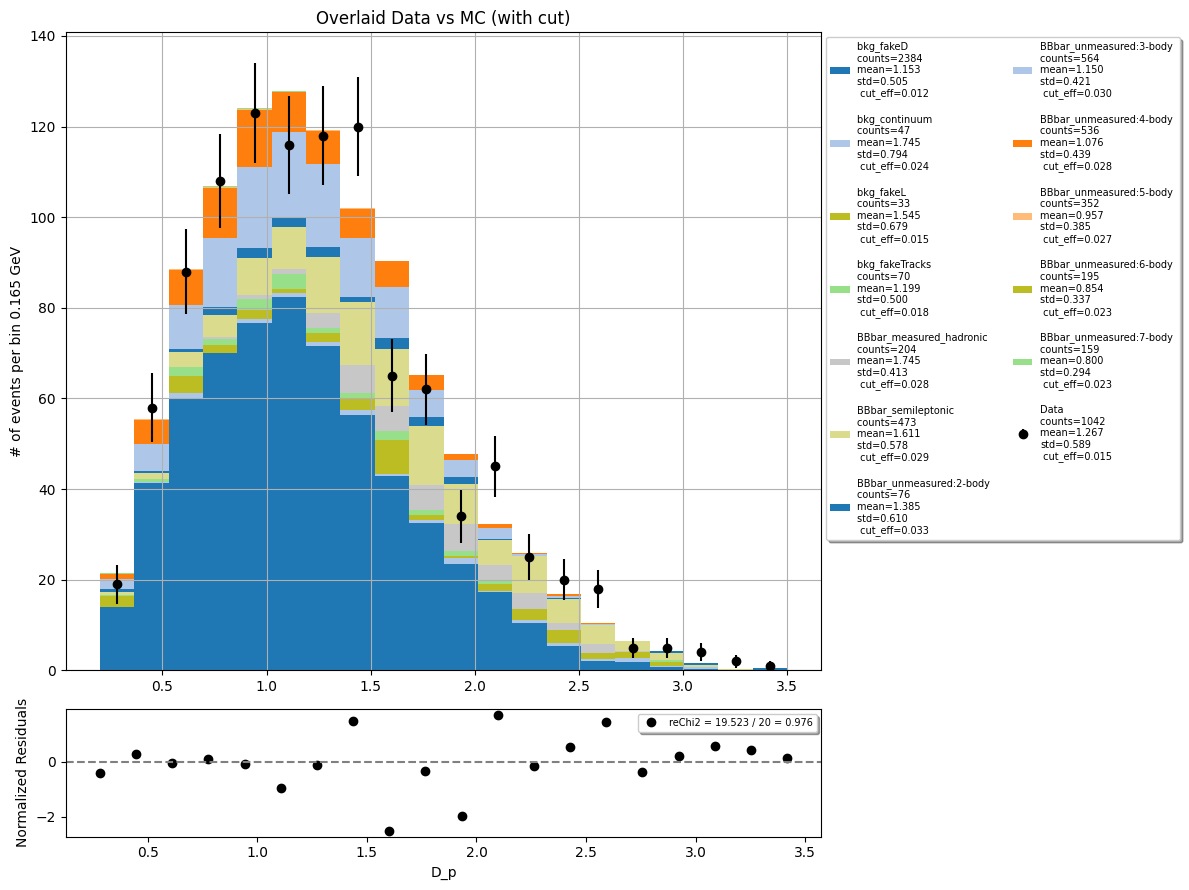

In [19]:
b1 = np.linspace(0.2,3.5,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl_wc.plot_data_mc_stacked(
    variable='D_p',bins=b1,cut='1.855<D_M<1.885 and B0_vtxReChi2>3 and experiment<18',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight') # 'total_PID_weigh'

cut= 1.855<D_M<1.885 and B0_vtxReChi2>3 and experiment<18


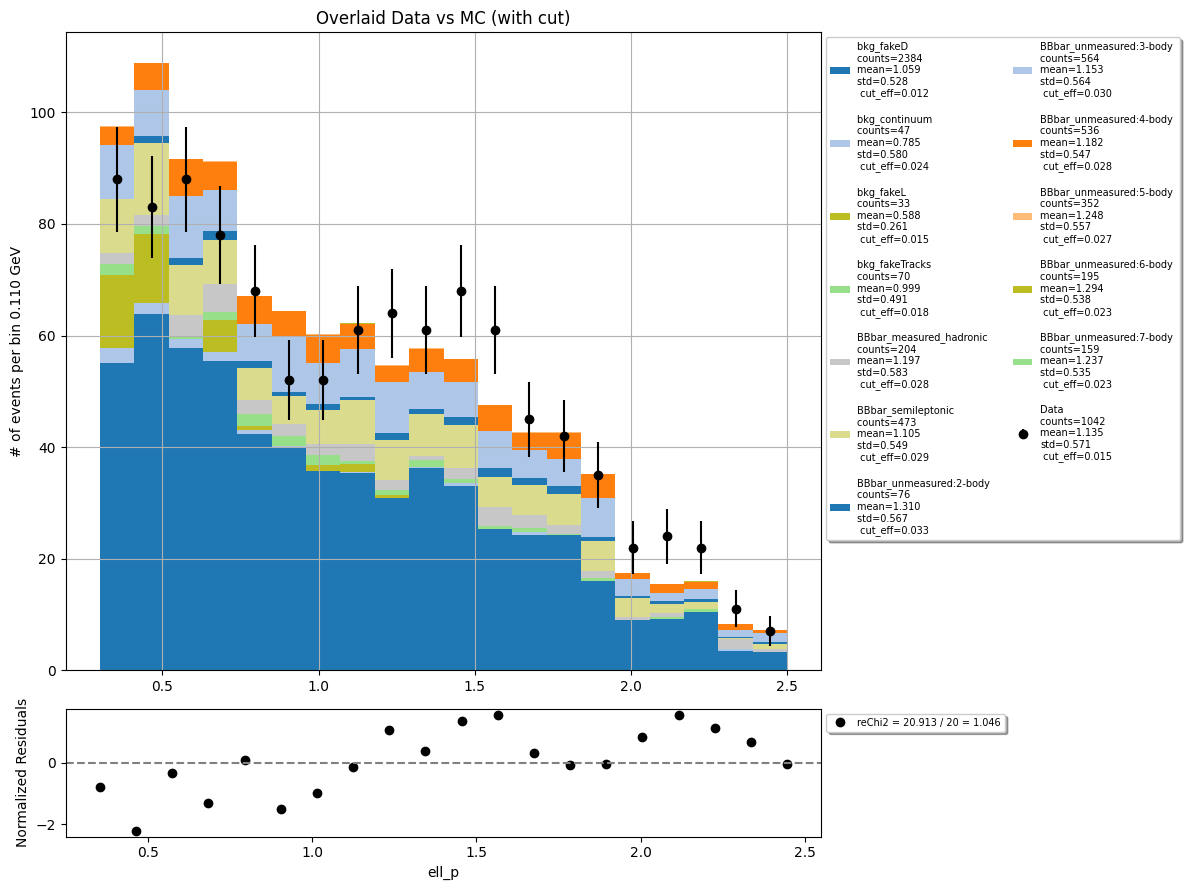

In [20]:
b1 = np.linspace(0.3,2.5,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl_wc.plot_data_mc_stacked(
    variable='ell_p',bins=b1,cut='1.855<D_M<1.885 and B0_vtxReChi2>3 and experiment<18',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight') # 'total_PID_weigh'

# 3. Fit combinatorial components

In [24]:
MM2_bins = np.linspace(-10,10,41)
p_D_l_bins = np.linspace(0.3,4.3,41)
MM2_bins_sb = np.linspace(-10,10,21)
p_D_l_bins_sb = np.linspace(0.3,4.3,21)
    
temp_data_sr,temp_data_sb,temp_data_sr_merged, temp_data_sb_merged = util.create_templates_new(
    samples=samples_wc_sub,cut='fakeD_prob<0.1',variables=['B0_recMissM2','p_D_l'],
    bins_sr=[MM2_bins, p_D_l_bins],bins_sb=[MM2_bins_sb, p_D_l_bins_sb],
     scale_lumi=1, bin_threshold=10,merge_threshold=5,
    use_real_data_instead_of_asimov=True, real_data=df_data_4S_wc,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight',
    sample_to_exclude=['bkg_other_TDTl','bkg_other_signal', 'others',
                      r'$D\ell\nu$_gap',
                       # 'bkg_fakeD', 
                       # 'bkg_continuum',
#                       r'$D^{\ast\ast}\ell\nu$_broad',
#                       r'$D^{\ast\ast}\ell\nu$_narrow',
#                       r'$D\ell\nu$',
#                       r'$D^\ast\ell\nu$',
#                       r'$D\tau\nu$', 
#                       r'$D^\ast\tau\nu$', 
#                       r'$D^{\ast\ast}\tau\nu$',
                      #  'bkg_fakeTracks',
                      # 'bkg_TDFl','bkg_singleBbkg',
                      # 'bkg_combinatorial',
                      ],
    sample_weights={#r'$D\ell\nu$_gap_pi':           0, # 2618 events 
                    r'$D\ell\nu$_gap':          0, # 2404
                    r'$D^{\ast\ast}\ell\nu$_broad': 0.25 * 1.435, # 11540 events from 1/ab
                    r'$D^{\ast\ast}\ell\nu$_narrow':0.25,
                    r'$D\ell\nu$':                  0.25,
                    r'$D^\ast\ell\nu$':             0.25,
                    r'$D\tau\nu$':                  0.25 , 
                    r'$D^\ast\tau\nu$':             0.25 , 
                    r'$D^{\ast\ast}\tau\nu$':       0.25 * 0.33,
                    'bkg_fakeD':                    0.25, # here for signal region
                    'bkg_fakeL':                    0.25,
                    'bkg_continuum':                0.25,
                    'bkg_combinatorial':            0.25,
                    'bkg_hadronicB_secondaryL':     0.25,
                    'bkg_fakeTracks':               0.25,
                    'BBbar_measured_hadronic':      0.25,
                    'BBbar_semileptonic':           0.25,
                    'BBbar_unmeasured:2-body':      0.25,
                    'BBbar_unmeasured:3-body':      0.25,
                    'BBbar_unmeasured:4-body':      0.25,
                    'BBbar_unmeasured:5-body':      0.25,
                    'BBbar_unmeasured:6-body':      0.25,
                    'BBbar_unmeasured:7-body':      0.25,
                    })

Creating templates for the signal region
Creating templates for D_M sidebands channel
creating new templates with merged bins in the signal region, original template length = 338, new template (merge small bins) length = 338
creating new templates with merged bins in the D mass sidebands, original template length = 95, new template (merge small bins) length = 95


In [25]:
import json
spec_wc_e = util.create_workspace(temp_data_channels=[temp_data_sr,temp_data_sb],mc_uncer=True,fakeD_uncer=True)
spec_wc_e['measurements'][0]['config']['poi']="BBbar_measured_hadronic_norm"
print(json.dumps(spec_wc_e, sort_keys=True, indent=4))

{
    "channels": [
        {
            "name": "channel_0",
            "samples": [
                {
                    "data": [
                        1.36,
                        1.61,
                        0.25,
                        1.35,
                        1.63,
                        1.7,
                        1.82,
                        1.51,
                        1.43,
                        3.45,
                        1.63,
                        2.14,
                        1.23,
                        2.17,
                        2.78,
                        3.95,
                        2.94,
                        3.27,
                        1.49,
                        0.47,
                        0.92,
                        2.88,
                        1.97,
                        4.8,
                        4.17,
                        10.58,
                        2.4,
                        2.04,
                        2.

In [26]:
import cabinetry, pyhf
cabinetry.set_logging()

INFO - pyhf.workspace - Validating spec against schema: workspace.json
INFO - pyhf.pdf - Validating spec against schema: model.json
INFO - pyhf.pdf - adding modifier BBbar_measured_hadronic_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_semileptonic_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_unmeasured:2-body_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_unmeasured:3-body_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_unmeasured:4-body_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_unmeasured:5-body_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_unmeasured:6-body_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_unmeasured:7-body_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier bkg_fakeD_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier bkg_continuum_norm (1 new nuisance

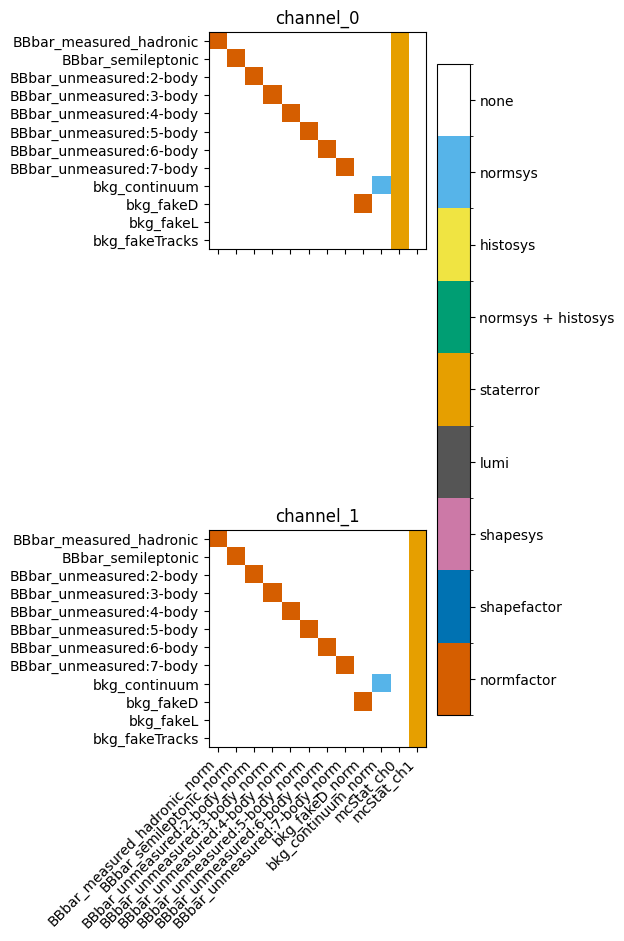

In [27]:
model_wc_e, data_wc_e = cabinetry.model_utils.model_and_data(spec_wc_e)
pars = model_wc_e.config.suggested_init()

norm_parameter_names = [par for par in model_wc_e.config.par_order if par.endswith('_norm')]
for par in norm_parameter_names:
    model_wc_e.config.param_set(par).suggested_bounds=[[0,1]]
    # if par=='SemileptonicB2D_PrimaryLepton_norm':
    #     model_comb.config.param_set(par).suggested_bounds=[[-0.9,1.1]]
    if par.startswith('$'):
        model_wc_e.config.param_set(par).suggested_fixed=[True]

model_wc_e.config.param_set('bkg_fakeD_norm').suggested_fixed=[False]
model_wc_e.config.param_set('bkg_continuum_norm').suggested_fixed=[True]
model_wc_e.config.param_set('BBbar_semileptonic_norm').suggested_fixed=[True]
model_wc_e.config.param_set('BBbar_measured_hadronic_norm').suggested_fixed=[False]
model_wc_e.config.param_set('BBbar_unmeasured:2-body_norm').suggested_init=[1]
model_wc_e.config.param_set('BBbar_unmeasured:2-body_norm').suggested_fixed=[False]
model_wc_e.config.param_set('BBbar_unmeasured:3-body_norm').suggested_init=[1]
model_wc_e.config.param_set('BBbar_unmeasured:3-body_norm').suggested_fixed=[False]
model_wc_e.config.param_set('BBbar_unmeasured:4-body_norm').suggested_init=[0.68]
model_wc_e.config.param_set('BBbar_unmeasured:5-body_norm').suggested_init=[0.1]
model_wc_e.config.param_set('BBbar_unmeasured:6-body_norm').suggested_init=[0.1]
model_wc_e.config.param_set('BBbar_unmeasured:7-body_norm').suggested_init=[0.1]

cabinetry.visualize.modifier_grid(model_wc_e)
# cabinetry.visualize.modifier_grid(pyhf.Workspace(spec_comb_e).model())

In [28]:
%%time
# e mode, staterror
fit_results = cabinetry.fit.fit(model=model_wc_e, data=data_wc_e,goodness_of_fit=True,
#                                 init_pars=[1]*7+[10]*3+pars[10:],
                                # fix_pars=[True]*4
                               )

INFO - cabinetry.fit - performing maximum likelihood fit
INFO - cabinetry.fit - Migrad status:
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1747                       │            Nfcn = 213072             │
│ EDM = 2.19e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴─────────────────────────────────

CPU times: user 1min 16s, sys: 98.7 ms, total: 1min 16s
Wall time: 1min 16s


# Check WC vs. CC

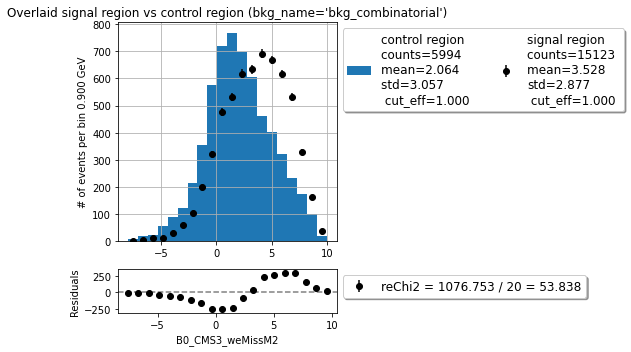

In [9]:
# compare control vs signal regions MC
b1 = np.linspace(-8,10,21)
weights = {'control region': 1,
         'signal region': 6/15}
mpl.plot_mc_sig_control(variable='B0_CMS3_weMissM2',bins=b1,
                        bkg_name='bkg_combinatorial',
                        cut=None,
                        samples_sig=samples_sig,
                        weights=weights,correction=False,mask=[])

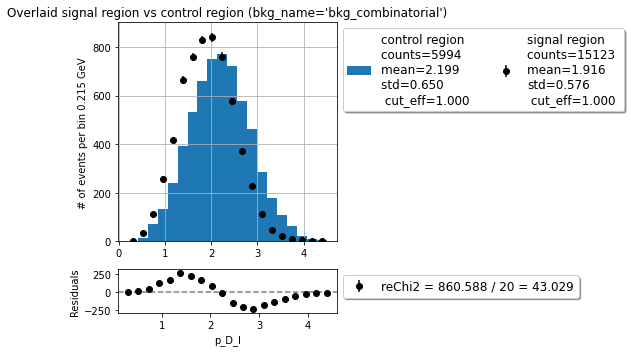

In [10]:
b2 = np.linspace(0.2,4.5,21)
mpl.plot_mc_sig_control(variable='p_D_l',bins=b2,
                        bkg_name='bkg_combinatorial',cut=None,
                        samples_sig=samples_sig,
                        weights=weights,correction=False,mask=[])

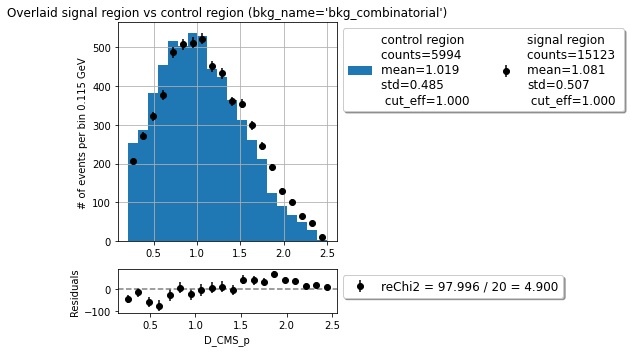

In [11]:
b2 = np.linspace(0.2,2.5,21)
mpl.plot_mc_sig_control(variable='D_CMS_p',bins=b2,
                        bkg_name='bkg_combinatorial',cut=None,
                        samples_sig=samples_sig,
                        weights=weights,correction=False,mask=[])

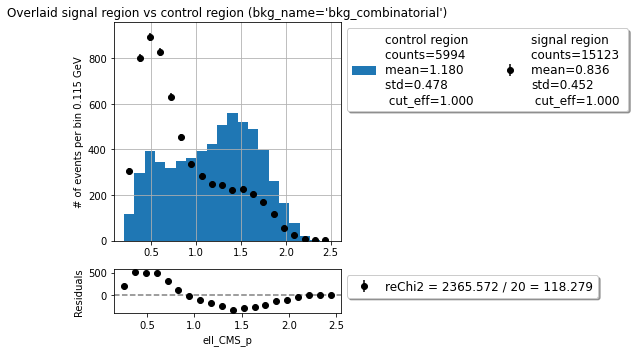

In [12]:
b2 = np.linspace(0.2,2.5,21)
mpl.plot_mc_sig_control(variable='ell_CMS_p',bins=b2,
                        bkg_name='bkg_combinatorial',cut=None,
                        samples_sig=samples_sig,
                        weights=weights,correction=False,mask=[])

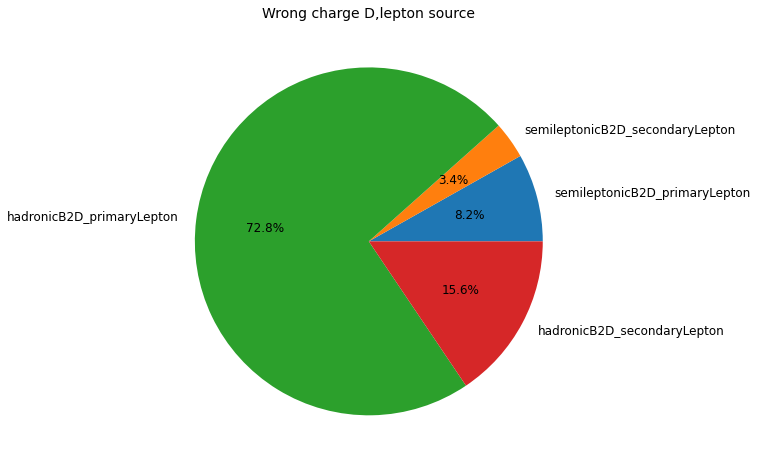

In [69]:
# Example data
sizes = [489, 205, 2872+1489, 458+474]  # Portion sizes for each component
labels = ['semileptonicB2D_primaryLepton', 'semileptonicB2D_secondaryLepton', 
          'hadronicB2D_primaryLepton','hadronicB2D_secondaryLepton']  # Names of each component

# Plotting the pie chart
plt.figure(figsize=(8, 8))  # Optional: adjust the size of the figure
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=0,textprops={'fontsize': 12})
plt.title('Wrong charge D,lepton source', fontsize=14)
plt.show()

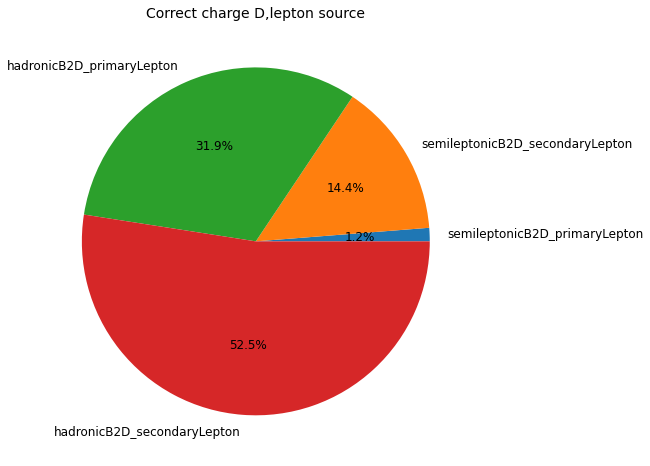

In [70]:
# Example data
sizes = [188, 2172, 1328+3495, 5215+2712]  # Portion sizes for each component
labels = ['semileptonicB2D_primaryLepton', 'semileptonicB2D_secondaryLepton', 
          'hadronicB2D_primaryLepton','hadronicB2D_secondaryLepton']  # Names of each component

# Plotting the pie chart
plt.figure(figsize=(8, 8))  # Optional: adjust the size of the figure
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=0,textprops={'fontsize': 12})
plt.title('Correct charge D,lepton source',fontsize=14)
plt.show()